### Trasformation 

\begin{equation}
E: (a, e, M, w)  \rightarrow X: (x,y,v_x, v_y)
\end{equation}

\begin{equation}
    \mathbb{J}_{X o E} =
    \begin{pmatrix} 
    \partial_ax & \partial_ex & \partial_wx & \partial_Mx\\
    \partial_ay & \partial_ey & \partial_wy & \partial_My \\
    \partial_av_x & \partial_ev_x & \partial_wv_x & \partial_Mv_x \\
    \partial_av_y & \partial_ev_y & \partial_wv_y & \partial_Mv_y 
    \end{pmatrix}
\end{equation}

In [3]:
import numpy as np
from Utils import CanonicalUnits, calcKeplerianJacobians, JaccobianComponents, Kepler, GravitationalParameters, X2E, computeNumericalJacobian, OrbitTrasformations
import spiceypy as spy
import scipy.optimize as optimize
from tqdm import tqdm
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.integrate import nquad
from numpy.polynomial.legendre import leggauss
from scipy.integrate import nquad
%load_ext autoreload 
%autoreload 2

In [4]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

In [6]:
def compute_functions(i: float, w: float, Omega: float, 
                    which: Set[str]) -> Dict[str, float]:
    """Compute transformation functions A, B, C, D, F, G"""
    results = {}
    
    if 'A' in which:
        results['A'] = (np.cos(Omega)*np.cos(w) - np.sin(Omega)*np.cos(i)*np.sin(w))
    if 'B' in which:
        results['B'] = (-np.cos(Omega)*np.sin(w) - np.sin(Omega)*np.cos(i)*np.cos(w))
    if 'C' in which:
        results['C'] = (np.sin(Omega)*np.cos(w) + np.cos(Omega)*np.cos(i)*np.sin(w))
    if 'D' in which:
        results['D'] = (-np.sin(Omega)*np.sin(w) + np.cos(Omega)*np.cos(i)*np.cos(w))
    
    return results

def compute_state_vector(E: np.array, mu: float) -> np.array:
    state_vector = spy.conics(E+[0, mu], 0)
    return state_vector

def jacobian_XoE(a: float, e: float, w: float, M: float, mu: float) -> np.array:
    i = 0
    Omega = 0
    E = optimize.newton(Kepler, M, args=(M, e))

    functions = compute_functions(i, w, Omega, {'A', 'B', 'C', 'D'})
    A = functions['A']
    B = functions['B']
    C = functions['C']
    D = functions['D']
    
    ot = OrbitTrasformations()
    r = ot.r(a, e, E)
    eps = ot.sqrt_e(e)
    nu = ot.nu(a, mu)
    nur = nu/r

    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    #partial a

    partial_a_x = state_vector[0]/a
    partial_a_y = state_vector[1]/a
    partial_a_vx = -state_vector[3]/(2*a)
    partial_a_vy = -state_vector[4]/(2*a)

    partial_a = [partial_a_x, partial_a_y, partial_a_vx, partial_a_vy]

    #partial e

    #dX/de
    dcosEde=-a*np.sin(E)**2/r       
    dsinEde=a*np.cos(E)*np.sin(E)/r
    dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
    depsde=-e/eps

    drAde=a*(dcosEde-1)
    drBde=a*(depsde*np.sin(E)+eps*dsinEde)

    dvAde=-(dnurde*np.sin(E)+nur*dsinEde)
    dvBde=(dnurde*eps*np.cos(E)+nur*depsde*np.cos(E)+nur*eps*dcosEde)

    partial_e = np.array([
        drAde*A+drBde*B,
        drAde*C+drBde*D,
        dvAde*A+dvBde*B,
        dvAde*C+dvBde*D
    ])

    #partial w

    partial_w_x = -state_vector[1]*np.cos(i) - state_vector[2]*np.sin(i)*np.cos(Omega)
    partial_w_y = state_vector[0]*np.cos(i) - state_vector[2]*np.sin(i)*np.sin(Omega)
    partial_w_vx = -state_vector[4]*np.cos(i) - state_vector[5]*np.sin(i)*np.cos(Omega)
    partial_w_vy = state_vector[3]*np.cos(i) - state_vector[5]*np.sin(i)*np.sin(Omega)

    partial_w = [partial_w_x, partial_w_y, partial_w_vx, partial_w_vy]

    #partial M
    n = (mu/a**3)**0.5
    factor = -(mu*a**3)**0.5/r**3

    partial_M_x = (1/n) * state_vector[3]
    partial_M_y = (1/n) * state_vector[4]
    partial_M_vx = factor * state_vector[0]
    partial_M_vy = factor * state_vector[1]

    partial_M = [partial_M_x, partial_M_y, partial_M_vx, partial_M_vy]

    J = np.zeros((4,4))
    J[:,0] = partial_a
    J[:,1] = partial_e
    J[:,2] = partial_w
    J[:,3] = partial_M
    
    return J


In [7]:
a = 0.5
e = 0.1
i = 0
Omega = 0
w = np.pi/2
M = np.pi
q = a*(1-e)

J = jacobian_XoE(a,e,w,M,mu)

Je2c=np.eye(4)
Je2c[0,0]=1/(1-e)
Je2c[0,1]=q/(1-e)**2
Jq=np.matmul(J,Je2c)
Jq

array([[ 2.34912103e-15,  1.20548516e-15,  5.50000000e-01,
         4.52267017e-01],
       [-1.22222222e+00, -1.11111111e+00,  1.05710446e-15,
         9.25934527e-16],
       [-8.93172099e+00, -1.25856068e+01, -1.64574680e-14,
        -1.41163557e-14],
       [-1.82860756e-14, -6.84694175e-15,  8.03854889e+00,
         7.34458692e+00]])

In [8]:
E = [q, e, 0, 0, w, M]
E2X = lambda E, mu: spy.conics(E+[0, mu], 0)
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JXoE=computeNumericalJacobian(E2X,E,dX,**args)
JXoE

array([[-1.36877367e-13, -2.72639618e-13,  0.00000000e+00,
         5.49999908e-01,  5.49999908e-01,  4.52266960e-01],
       [-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.11022302e-13],
       [ 0.00000000e+00,  0.00000000e+00, -5.49999908e-01,
         0.00000000e+00,  0.00000000e+00, -0.00000000e+00],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-3.59016386e-12, -1.79957317e-12,  0.00000000e+00,
         8.03854755e+00,  8.03854755e+00,  7.34458628e+00],
       [-0.00000000e+00,  0.00000000e+00,  5.69401612e-15,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [9]:
Jcomp = np.zeros((4,4))
Jcomp[0,0] = JXoE[0,0]
Jcomp[0,1] = JXoE[0,1]
Jcomp[0,2] = JXoE[0,4]
Jcomp[0,3] = JXoE[0,5]
Jcomp[1,0] = JXoE[1,0]
Jcomp[1,1] = JXoE[1,1]
Jcomp[1,2] = JXoE[1,4]
Jcomp[1,3] = JXoE[1,5]
Jcomp[2,0] = JXoE[3,0]
Jcomp[2,1] = JXoE[3,1]
Jcomp[2,2] = JXoE[3,4]
Jcomp[2,3] = JXoE[3,5]
Jcomp[3,0] = JXoE[4,0]
Jcomp[3,1] = JXoE[4,1]
Jcomp[3,2] = JXoE[4,4]
Jcomp[3,3] = JXoE[4,5]
Jcomp


array([[-1.36877367e-13, -2.72639618e-13,  5.49999908e-01,
         4.52266960e-01],
       [-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
        -1.11022302e-13],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00],
       [-3.59016386e-12, -1.79957317e-12,  8.03854755e+00,
         7.34458628e+00]])

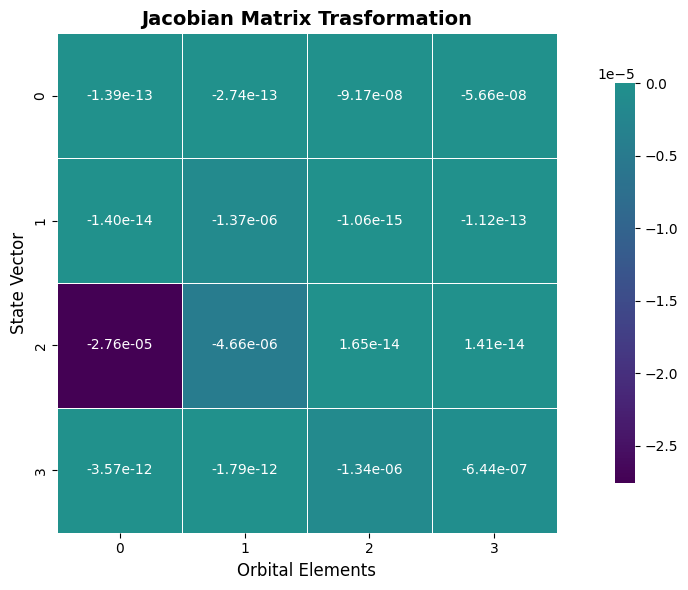

In [10]:
plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(Jcomp - Jq, 
            annot=True, 
            fmt='.2e', 
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Trasformation', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
def trasformation_aewE_to_xyvxvy(a: float, e: float, w: float, M: float, mu: float) -> tuple[float, float, float, float]:
    Omega = 0
    i = 0
    q = a*(1-e)

    state_vec = compute_state_vector([q, e, i, Omega, w, M], mu)
    x = state_vec[0]
    y = state_vec[1]
    vx = state_vec[3]
    vy = state_vec[4]

    return x, y, vx, vy

def trasformation_xyvxvy_to_aewE(x: float, y: float, vx: float, vy: float, mu: float) -> tuple[float, float, float, float]:

    elements = spy.oscelt([x, y, 0, vx, vy, 0], et=0, mu=mu)
    q = elements[0]
    e = elements[1]
    w = elements[4]
    M = elements[5]
    a = q/(1-e)

    return a, e, w, M

In [13]:
N = int(1e7)

a_uniform = np.random.uniform(0, 2, N)
e_uniform = np.random.uniform(0, 1, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)
q_uniform = a_uniform*(1-e_uniform)

x_uniform, y_uniform, vx_uniform, vy_uniform = trasformation_aewE_to_xyvxvy(a_uniform[0], e_uniform[0], w_uniform[0], M_uniform[0], mu)
x_uniform, y_uniform, vx_uniform, vy_uniform

(0.10714189572067595,
 -0.7180727712579138,
 7.78378938978505,
 0.5010011156412144)

In [14]:
a_inverse, e_inverse, w_inverse, M_inverse = trasformation_xyvxvy_to_aewE(x_uniform, y_uniform, vx_uniform, vy_uniform, mu)
a_inverse, e_inverse, w_inverse, M_inverse 

(0.8236593515748437,
 0.14479614908493527,
 4.159978827975548,
 0.5285462791896159)

In [15]:
jacobian_XoE(q_uniform[1], e_uniform[1], w_uniform[1], M_uniform[1], mu)

array([[-1.45831629, -0.47469302, -0.10436292, -0.04046069],
       [ 0.21679799,  0.08050791, -0.70200902, -0.28457516],
       [ 0.79070341,  0.97750867,  5.35424565,  4.12143306],
       [ 5.56131292,  6.90922028, -0.76126273, -0.6127055 ]])

In [16]:
xyvxvy = np.zeros((N, 4))

for el in tqdm(range(N)):
    a = a_uniform[el]
    e = e_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]

    x, y, vx, vy = trasformation_aewE_to_xyvxvy(a, e, w, M, mu)
    xyvxvy[el] = np.array([x, y, vx, vy])

  0%|          | 0/10000000 [00:00<?, ?it/s]

100%|██████████| 10000000/10000000 [01:41<00:00, 98435.56it/s]


In [17]:
xyvxvy

array([[ 0.1071419 , -0.71807277,  7.78378939,  0.50100112],
       [-1.33557286,  0.19855056, -0.55191491, -3.88182404],
       [-0.9500087 ,  0.73296319, -3.95203586, -4.585958  ],
       ...,
       [-1.94929905,  0.92748925, -0.42764022, -3.62267981],
       [ 0.37629009, -1.0590252 ,  5.26002258,  2.24356558],
       [ 0.84772363,  1.53885332, -4.08266652,  2.11574024]])

In [52]:
import sys
sys.getsizeof(xyvxvy[0,0])

32

In [28]:
def P_aewM() -> float:
    a_max = 2; a_min = 0
    e_max = 1; e_min = 0
    w_max = 2*np.pi; w_min = 0
    M_max = 2*np.pi; M_min = 0
    return 1/(a_max - a_min) * 1/(e_max - e_min) * 1/(w_max - w_min) * 1/(M_max - M_min)

def P_xyvxvy(x: float, y: float, vx: float, vy: float) -> float:
    a, e, w, M = trasformation_xyvxvy_to_aewE(x, y, vx, vy, mu)
    J = jacobian_XoE(a,e,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_aewM() * abs(det)
    return P

def P_xyvxvy_vectorized(x: np.array, y: np.array, vx: np.array, vy: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    vx = np.asarray(vx)
    vy = np.asarray(vy)

    # Prepare output array
    shape = np.broadcast(x, y, vx, vy).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()

    for idx in range(x_flat.size):
        a, e, w, M = trasformation_xyvxvy_to_aewE(x_flat[idx], y_flat[idx], vx_flat[idx], vy_flat[idx], mu)
        J = jacobian_XoE(a,e,w,M,mu)
        #det = np.linalg.det(J)/(1-e)
        det = 1.0/np.linalg.det(J)
        P.flat[idx] = P_aewM() * abs(det)

    return P.reshape(shape)


## Probabilidad en un hipercubo

In [29]:
def surface_integral_P_xyvxvy(center, widths, n_points=8, mu=1):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, vx0, vy0 = center
    dx, dy, dvx, dvy = widths

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts

    # Create meshgrid of all quadrature points
    X, Y, VX, VY = np.meshgrid(x_pts, y_pts, vx_pts, vy_pts, indexing='ij')
    WX, WY, WVX, WVY = np.meshgrid(wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    WF = (WX * WY * WVX * WVY).ravel()

    # Evaluate P at all points
    Pf = P_xyvxvy_vectorized(Xf, Yf, VXf, VYf, mu)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dvx) * (0.5*dvy)
    return integral

In [30]:
# Example: Compare theoretical (integral) and numerical (count) number of objects in a phase-space volume

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
v_x = 0
v_y = (mu/1)**0.5

dxy = 0.5
dvxy = 5000 * (1/AU_m) * year

center = (c_x, c_y, v_x, v_y)
widths = (dxy, dxy, dvxy, dvxy)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_xyvxvy(center, widths, n_points=8, mu=mu)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(xyvxvy[:,0] - c_x) <= dxy/2) 
objsy = (abs(xyvxvy[:,1] - c_y) <= dxy/2) 
objsvx = (abs(xyvxvy[:,2] - v_x) <= dvxy/2) 
objsvy = (abs(xyvxvy[:,3] - v_y) <= dvxy/2) 

objects = objsx & objsy & objsvx & objsvy
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')

Theoretical (integral) number of objects in volume: 11775.825215646433
Numerical (count) number of objects inside volume: 11775


In [31]:
(N_theoretical * N)/N_numeric

1.0000700820081896

In [1]:
def integrate_xy(vx, vy, a, b, r, n_r=50, n_theta=100):
    rs, ws_r = np.polynomial.legendre.leggauss(n_r)
    # Transformar de [-1,1] a [0, r]
    rs = 0.5 * (rs + 1) * r
    ws_r = ws_r * 0.5 * r  # dr = r/2

    # Cuadratura gaussiana en theta de 0 a 2pi
    thetas, ws_theta = np.polynomial.legendre.leggauss(n_theta)
    thetas = 0.5 * (thetas + 1) * 2 * np.pi
    ws_theta = ws_theta * np.pi  # dtheta = pi

    # Crear mallas para r y theta
    rs_mesh, thetas_mesh = np.meshgrid(rs, thetas, indexing='ij')
    ws_r_mesh, ws_theta_mesh = np.meshgrid(ws_r, ws_theta, indexing='ij')

    # Coordenadas cartesianas
    xs = a + rs_mesh * np.cos(thetas_mesh)
    ys = b + rs_mesh * np.sin(thetas_mesh)

    # Evaluar la función en la malla
    integrando = P_xyvxvy_vectorized(xs, ys, vx, vy) * rs_mesh

    # Sumar todos los puntos ponderados
    integral = np.sum(integrando * ws_r_mesh * ws_theta_mesh)
    return integral

# Outer integral over infinite vx, vy using nquad
def hybrid_integral(a, b, r, n=20):
    def integrand(vx, vy):
        return integrate_xy(vx, vy, a, b, r, n=n)

    # nquad over (-∞, ∞) × (-∞, ∞)
    result, err = nquad(integrand, [[-np.inf, np.inf], [-np.inf, np.inf]])
    return result, err

In [2]:
#center 
a = 1; b = 0
r = 0.2

res, err = hybrid_integral(a, b, r, n=20)
print("Integral result:", res, " ± ", err)

NameError: name 'nquad' is not defined

### Integral over $x, y$ in close range [a, b] and $v_x, v_y$ over $(-\infty, \infty)$

In [40]:
def P_aewM() -> float:
    a_max = 2; a_min = 0
    e_max = 1; e_min = 0
    w_max = 2*np.pi; w_min = 0
    M_max = 2*np.pi; M_min = 0
    return 1/(a_max - a_min) * 1/(e_max - e_min) * 1/(w_max - w_min) * 1/(M_max - M_min)

def P_xyvxvy(x: float, y: float, vx: float, vy: float) -> float:
    mu = 39.48894168123623
    a, e, w, M = trasformation_xyvxvy_to_aewE(x, y, vx, vy, mu)
    J = jacobian_XoE(a,e,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_aewM() * abs(det)
    return P

def P_xyvxvy_vectorized(x: np.array, y: np.array, vx: np.array, vy: np.array) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    mu = 39.48894168123623
    
    x = np.asarray(x)
    y = np.asarray(y)
    vx = np.asarray(vx)
    vy = np.asarray(vy)

    # Prepare output array
    shape = np.broadcast(x, y, vx, vy).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()

    for idx in range(x_flat.size):
        a, e, w, M = trasformation_xyvxvy_to_aewE(x_flat[idx], y_flat[idx], vx_flat[idx], vy_flat[idx], mu)
        J = jacobian_XoE(a,e,w,M,mu)
        #det = np.linalg.det(J)/(1-e)
        det = 1.0/np.linalg.det(J)
        P.flat[idx] = P_aewM() * abs(det)

    return P.reshape(shape)

In [50]:
# Finite-range Gauss–Legendre integration over x,y
def integrate_xy(vx, vy, ax, bx, ay, by, n=20):
    # Gauss–Legendre nodes and weights
    nodes, weights = leggauss(n)

    # Map nodes from [-1, 1] to [ax, bx] and [ay, by]
    x_nodes = 0.5 * (nodes * (bx - ax) + (bx + ax))
    y_nodes = 0.5 * (nodes * (by - ay) + (by + ay))
    x_weights = 0.5 * (bx - ax) * weights
    y_weights = 0.5 * (by - ay) * weights

    # Tensor product quadrature
    total = 0.0
    for i, xi in enumerate(x_nodes):
        for j, yj in enumerate(y_nodes):
            total += P_xyvxvy(xi, yj, vx, vy) * x_weights[i] * y_weights[j]
    return total

# Outer integral over infinite vx, vy using nquad
def hybrid_integral(ax, bx, ay, by, n=20):
    def integrand(vx, vy):
        return integrate_xy(vx, vy, ax, bx, ay, by, n=n)

    # nquad over (-∞, ∞) × (-∞, ∞)
    result, err = nquad(integrand, [[-np.inf, np.inf], [-np.inf, np.inf]])
    print(result)
    return result, err

# Example usage
res, err = hybrid_integral(0, 0.25, -0.5, 0.5, n=20)
print("Integral result:", res, " ± ", err)


C:\Users\aguju\AppData\Local\Temp\ipykernel_12620\267637547.py:81: RuntimeWarning: invalid value encountered in scalar power
  n = (mu/a**3)**0.5
C:\Users\aguju\AppData\Local\Temp\ipykernel_12620\267637547.py:82: RuntimeWarning: invalid value encountered in scalar power
  factor = -(mu*a**3)**0.5/r**3


RuntimeError: Failed to converge after 50 iterations, value is 226.43353653218716.

In [46]:
ax = 0.75;  ay = 1.25; bx = -0.25; by = 0.25
n=20
nodes, weights = leggauss(n)

# Map nodes from [-1, 1] to [ax, bx] and [ay, by]
x_nodes = 0.5 * (nodes * (bx - ax) + (bx + ax))
y_nodes = 0.5 * (nodes * (by - ay) + (by + ay))
x_weights = 0.5 * (bx - ax) * weights
y_weights = 0.5 * (by - ay) * weights

# Tensor product quadrature
total = 0.0
for i, xi in enumerate(x_nodes):
    for j, yj in enumerate(y_nodes):
        total += P_xyvxvy(xi, yj, vx, vy) * x_weights[i] * y_weights[j]
        print(total)

9.627231469408307e-08
3.2635472442357745e-07
7.055116946763246e-07
1.2598962446086473e-06
2.0311423235505725e-06
3.0849031239737587e-06
4.525454650309704e-06
6.5078643495611264e-06
9.153514385438683e-06
1.2105953517518463e-05
1.4587008911224605e-05
1.641585000664154e-05
1.7749242905716617e-05
1.873323640234175e-05
1.9463854279903663e-05
2.0002992358377847e-05
2.039165290149617e-05
2.0657433267587473e-05
2.0818513445996846e-05
2.088583924032334e-05
2.1111228751651683e-05
2.1650128348393665e-05
2.2539010437399502e-05
2.3840854371441743e-05
2.5657241253487533e-05
2.815196104203679e-05
3.159573117113495e-05
3.642460932721114e-05
4.30730483484241e-05
5.060018341107696e-05
5.6727150808948135e-05
6.111034193339229e-05
6.425628306242566e-05
6.6559007992997e-05
6.826082703960455e-05
6.951294183004399e-05
7.041378629553017e-05
7.10289692820359e-05
7.140147190639363e-05
7.155708779694827e-05
7.191397717870579e-05
7.276789942222546e-05
7.417850733280502e-05
7.625012044280773e-05
7.915463582213856e

In [ ]:
widths

(0.5, 0.5, 1.0547326203208556, 1.0547326203208556)

In [49]:
center[1] + widths[1], center[1] - widths[1]

(0.5, -0.5)